In [3]:
from loader import load_data

(x, y_gt) = load_data(filename="function_approximation.csv")

print("x:", x)
print("y_gt:", y_gt)

x: [[-1.91836735]
 [-1.83673469]
 [-1.75510204]
 [-1.67346939]
 [-1.59183673]
 [-1.51020408]
 [-1.42857143]
 [-1.34693878]
 [-1.26530612]
 [-1.18367347]
 [-1.10204082]
 [-1.02040816]
 [-0.93877551]
 [-0.85714286]
 [-0.7755102 ]
 [-0.69387755]
 [-0.6122449 ]
 [-0.53061224]
 [-0.44897959]
 [-0.36734694]
 [-0.28571429]
 [-0.20408163]
 [-0.12244898]
 [-0.04081633]
 [ 0.04081633]
 [ 0.12244898]
 [ 0.20408163]
 [ 0.28571429]
 [ 0.36734694]
 [ 0.44897959]
 [ 0.53061224]
 [ 0.6122449 ]
 [ 0.69387755]
 [ 0.7755102 ]
 [ 0.85714286]
 [ 0.93877551]
 [ 1.02040816]
 [ 1.10204082]
 [ 1.18367347]
 [ 1.26530612]
 [ 1.34693878]
 [ 1.42857143]
 [ 1.51020408]
 [ 1.59183673]
 [ 1.67346939]
 [ 1.75510204]
 [ 1.83673469]
 [ 1.91836735]
 [ 2.        ]]
y_gt: [[ 0.87234069]
 [ 0.96476195]
 [ 0.55007439]
 [-0.08751399]
 [-0.65076533]
 [-0.95893659]
 [-0.9705199 ]
 [-0.74295438]
 [-0.37665614]
 [ 0.02884405]
 [ 0.39849371]
 [ 0.68822427]
 [ 0.88119326]
 [ 0.97987432]
 [ 0.99792581]
 [ 0.9537099 ]
 [ 0.86594599]


a) Make a plot of the function. Notice that the function has both positive and
negative values.

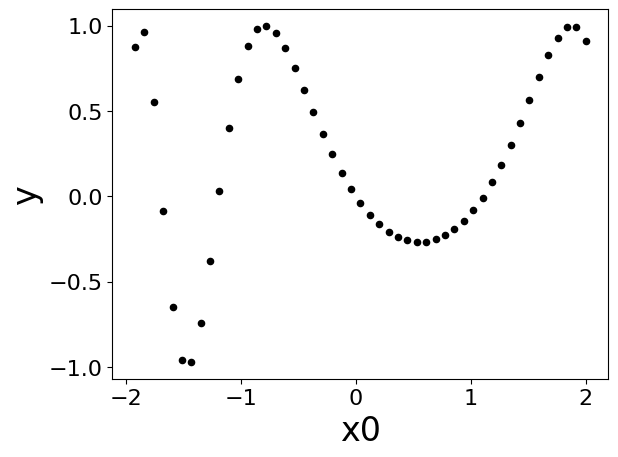

In [4]:
from plotting import plot_data_1d
plot_data_1d(x, y_gt)

b)Modify the training loop from the previous example to train a network to
approximate the function. Plot the evolution of the error and the final function
approximation. Hint: you will need to modify the activation function. One option is
to use a tanh-activation function. The derivative of the tanh-function is given by
tanh’(𝑥) = 1 − tanh(𝑥)). Use 𝜂 ≈ 0.1

In [5]:
import numpy as np

def tanh(x):
    return np.tanh(x)

def d_tanh(x):
    return 1 - np.tanh(x) ** 2

def dnn2_tanh(wa, ba, wb, bb, x):
    y_a = tanh(x @ wa + ba)
    y_b = tanh(y_a @ wb + bb)
    return y_b

In [6]:
from numpy.random import default_rng

num_neurons = 10
rng = default_rng(seed=42)
wa = rng.standard_normal(size=(1, num_neurons))
ba = rng.standard_normal(size=(1, num_neurons))
wb = rng.standard_normal(size=(num_neurons, 1))
bb = rng.standard_normal(size=(1, 1))

num_samples          = len(x)
num_train_iterations = 10 ** 5
eta                  = 0.1
errors               = []

In [8]:
from numpy import reshape, sum, transpose

for i in range(num_train_iterations):
    selected      = rng.integers(0, num_samples)
    x_selected    = reshape(x[selected], (1, -1))
    y_gt_selected = reshape(y_gt[selected], (1, -1))

    p_a    = x_selected @ wa + ba
    y_a    = tanh(p_a)

    p_b    = y_a @ wb + bb
    y_p    = tanh(p_b)

    error  = y_p - y_gt_selected

    delta_b = error * d_tanh(p_b)
    wb      = wb - eta * delta_b * transpose(y_a)
    bb      = bb - eta * delta_b

    delta_a = sum(wb * delta_b, axis=1) * d_tanh(p_a)
    wa      = wa - eta * delta_a * transpose(x_selected)
    ba      = ba - eta * delta_a

    errors.append(error[0, 0] ** 2)

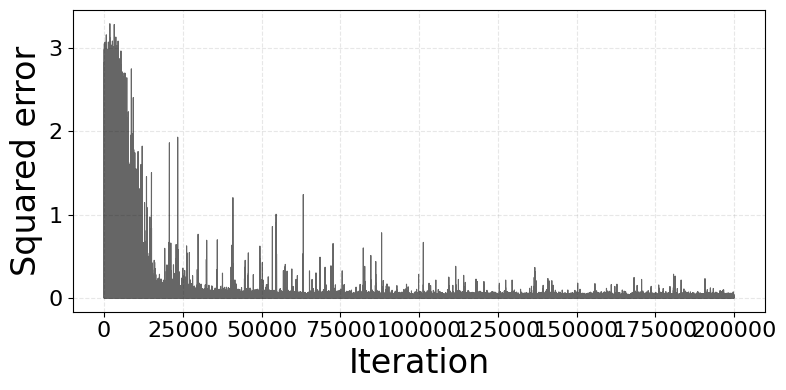

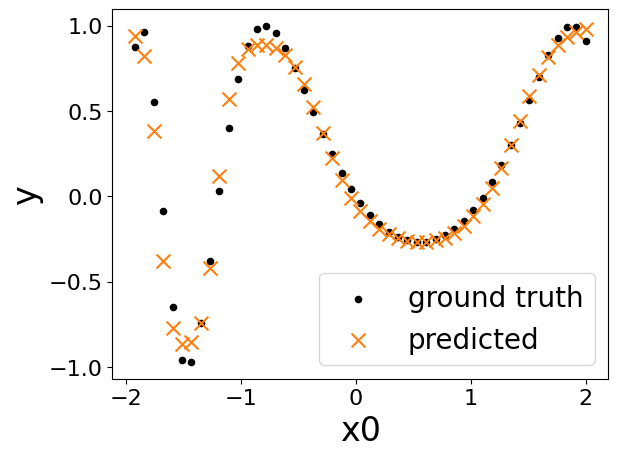

In [9]:
from plotting import plot_pred_1d, plot_errors

plot_errors(errors)
plot_pred_1d(x, y_gt, y_p=dnn2_tanh(wa, ba, wb, bb, x))

c) Modify the network by adding another hidden layer, and train the modified
network. Plot again the error and the final function approximation. Hint: use 𝜂 ≈
0.1

In [10]:
def dnn3_tanh(wa, ba, wb, bb, wc, bc, x):
    y_a = tanh(x  @ wa + ba)
    y_b = tanh(y_a @ wb + bb)
    y_c = tanh(y_b @ wc + bc)
    return y_c


In [11]:
num_neurons = 10
rng = default_rng(seed=42)
wa = rng.standard_normal(size=(1,          num_neurons))
ba = rng.standard_normal(size=(1,          num_neurons))
wb = rng.standard_normal(size=(num_neurons, num_neurons))
bb = rng.standard_normal(size=(1,          num_neurons))
wc = rng.standard_normal(size=(num_neurons, 1))
bc = rng.standard_normal(size=(1,          1))

In [12]:
errors = []

for i in range(num_train_iterations):
    selected      = rng.integers(0, num_samples)
    x_selected    = reshape(x[selected], (1, -1))
    y_gt_selected = reshape(y_gt[selected], (1, -1))

    p_a    = x_selected @ wa + ba
    y_a    = tanh(p_a)

    p_b    = y_a @ wb + bb
    y_b    = tanh(p_b)

    p_c    = y_b @ wc + bc
    y_p    = tanh(p_c)

    error  = y_p - y_gt_selected

    delta_c = error * d_tanh(p_c)
    wc      = wc - eta * delta_c * transpose(y_b)
    bc      = bc - eta * delta_c

    delta_b = sum(wc * delta_c, axis=1) * d_tanh(p_b)
    wb      = wb - eta * delta_b * transpose(y_a)
    bb      = bb - eta * delta_b

    delta_a = sum(wb * delta_b, axis=1) * d_tanh(p_a)
    wa      = wa - eta * delta_a * transpose(x_selected)
    ba      = ba - eta * delta_a

    errors.append(error[0, 0] ** 2)

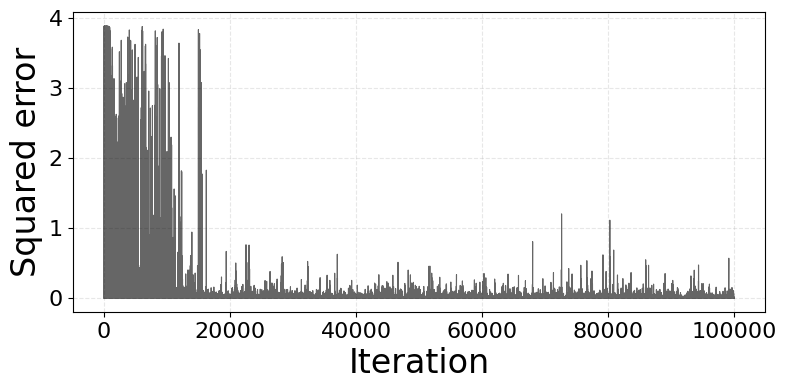

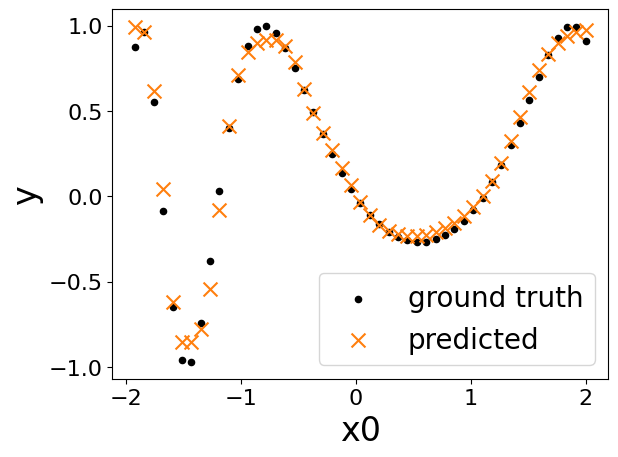

In [17]:
plot_errors(errors)
plot_pred_1d(x, y_gt, y_p=dnn3_tanh(wa, ba, wb, bb, wc, bc, x))